# Week 10: Text as Data

## Setting Up

Run this if packages are missing:

```bash
!pip install nltk wordcloud matplotlib pandas
!pip install jieba
```

In [3]:
import re
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import nltk
import pandas as pd
from wordcloud import STOPWORDS as WORDCLOUD_STOPWORDS
from wordcloud import WordCloud
import jieba # This one is for Chinese tokenization

In [4]:
# This cell will download things we need onto your laptop
import contextlib, io

resources = {
    "punkt": "tokenizers/punkt",
    "punkt_tab": "tokenizers/punkt_tab",
    "stopwords": "corpora/stopwords",
    "wordnet": "corpora/wordnet",
    "omw-1.4": "corpora/omw-1.4",
    "averaged_perceptron_tagger_eng": "taggers/averaged_perceptron_tagger_eng",
}

for package, lookup_path in resources.items():
    try:
        nltk.data.find(lookup_path)
    except LookupError:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            nltk.download(package, quiet=True, raise_on_error=False)

## Reading Data

In [5]:
csv_path = 'threads.csv'
df = pd.read_csv(csv_path)
df.head()

,item_id,text,datalike_count
0,3890170466896259347_66660792505,台北鼠患問題有人點名阿扁總統，但都沒有看到大家詢問應該最有資格回應的郝龍斌前市長，人家當年可...,29
1,3890172957516062340_67462622698,看到老鼠不要拍照不要上傳，就沒有鼠患這件事。\n器官活摘不要報導不要上傳，就沒有器官活摘這件...,34
2,3890179955695264381_63243585971,為沈伯洋啟動大罷免模式？！\n被揭發造假就送老鼠到學校住宅區？！\n#王鴻薇 #立法院,6
3,3888994203631473327_64425309222,鼠一鼠二鼠到三，給大家看老家鄰居在門口養的小米奇。,5156
4,3889537591210080283_67525438783,老鼠不會笨到跳進一個跳不回來的地方覓食。給中央廚房的意見。增加故事的可信度～,3642


In [48]:
custom_terms = ['台北市', '蔣萬安', '王鴻薇', '郝龍斌', '鼠患', '寵物溝通師']
for term in custom_terms:
    jieba.add_word(term)
with open("chinese_stopwords.txt", "r", encoding="utf-8") as f:
    STOPWORDS = f.read().splitlines()

## Preprocessing

In [49]:
# Remove NA
df['clean_text'] = df['text'].fillna('').astype(str)
df['clean_text']

0      台北鼠患問題有人點名阿扁總統，但都沒有看到大家詢問應該最有資格回應的郝龍斌前市長，人家當年可...
1      看到老鼠不要拍照不要上傳，就沒有鼠患這件事。\n器官活摘不要報導不要上傳，就沒有器官活摘這件...
2            為沈伯洋啟動大罷免模式？！\n被揭發造假就送老鼠到學校住宅區？！\n#王鴻薇 #立法院
3                              鼠一鼠二鼠到三，給大家看老家鄰居在門口養的小米奇。
4                 老鼠不會笨到跳進一個跳不回來的地方覓食。給中央廚房的意見。增加故事的可信度～
                             ...                        
245    抓老鼠抓老鼠我會抓老鼠～老鼠早就很多了（這是去年），只是現在特別囂張，榮星花園和大安森林公園...
246    現在看到台北一堆老鼠\n就想到我家紗窗被老鼠咬破還入侵我房間\n而且老鼠超愛吃巧克力 把我的...
247                  昨天看到很多人說台北根本沒老鼠\n今天在Y28又遇到一隻 媽的有夠可愛
248    台北市的餐飲業者與攤商們\n\n很抱歉，為了生命與健康\n\n真的必需公開說、在滿街老鼠的狀...
249    傾聽在地人的聲音： \n「大家好，我是老鼠，我在信義區出生，這次台北市長選舉我堅定支持蔣萬安...
Name: clean_text, Length: 250, dtype: str

In [50]:
# Remove literal "\n"
df['clean_text'] = df['clean_text'].str.replace(r'\\n', ' ', regex=True)
df['clean_text']

0      台北鼠患問題有人點名阿扁總統，但都沒有看到大家詢問應該最有資格回應的郝龍斌前市長，人家當年可...
1      看到老鼠不要拍照不要上傳，就沒有鼠患這件事。 器官活摘不要報導不要上傳，就沒有器官活摘這件事...
2              為沈伯洋啟動大罷免模式？！ 被揭發造假就送老鼠到學校住宅區？！ #王鴻薇 #立法院
3                              鼠一鼠二鼠到三，給大家看老家鄰居在門口養的小米奇。
4                 老鼠不會笨到跳進一個跳不回來的地方覓食。給中央廚房的意見。增加故事的可信度～
                             ...                        
245    抓老鼠抓老鼠我會抓老鼠～老鼠早就很多了（這是去年），只是現在特別囂張，榮星花園和大安森林公園...
246    現在看到台北一堆老鼠 就想到我家紗窗被老鼠咬破還入侵我房間 而且老鼠超愛吃巧克力 把我的零食...
247                   昨天看到很多人說台北根本沒老鼠 今天在Y28又遇到一隻 媽的有夠可愛
248    台北市的餐飲業者與攤商們  很抱歉，為了生命與健康  真的必需公開說、在滿街老鼠的狀況改善之...
249    傾聽在地人的聲音：  「大家好，我是老鼠，我在信義區出生，這次台北市長選舉我堅定支持蔣萬安！...
Name: clean_text, Length: 250, dtype: str

In [51]:
# Keep only Chinese, English, and whitespace
df['clean_text'] = df['clean_text'].str.replace(r'[^\u4e00-\u9fffA-Za-z\s]', ' ', regex=True)
df['clean_text']

0      台北鼠患問題有人點名阿扁總統 但都沒有看到大家詢問應該最有資格回應的郝龍斌前市長 人家當年可...
1      看到老鼠不要拍照不要上傳 就沒有鼠患這件事  器官活摘不要報導不要上傳 就沒有器官活摘這件事...
2              為沈伯洋啟動大罷免模式   被揭發造假就送老鼠到學校住宅區    王鴻薇  立法院
3                              鼠一鼠二鼠到三 給大家看老家鄰居在門口養的小米奇 
4                 老鼠不會笨到跳進一個跳不回來的地方覓食 給中央廚房的意見 增加故事的可信度 
                             ...                        
245    抓老鼠抓老鼠我會抓老鼠 老鼠早就很多了 這是去年  只是現在特別囂張 榮星花園和大安森林公園...
246    現在看到台北一堆老鼠 就想到我家紗窗被老鼠咬破還入侵我房間 而且老鼠超愛吃巧克力 把我的零食...
247                   昨天看到很多人說台北根本沒老鼠 今天在Y  又遇到一隻 媽的有夠可愛
248    台北市的餐飲業者與攤商們  很抱歉 為了生命與健康  真的必需公開說 在滿街老鼠的狀況改善之...
249    傾聽在地人的聲音    大家好 我是老鼠 我在信義區出生 這次台北市長選舉我堅定支持蔣萬安 ...
Name: clean_text, Length: 250, dtype: str

In [32]:
# Only for Chinese (and CJK languages): Tokenisation
raw_tokens = [jieba.lcut(x) for x in df['clean_text']]
df['raw_tokens'] = raw_tokens
df['raw_tokens']

0      [台北, 鼠患, 問題, 有人, 點名, 阿扁, 總統,  , 但, 都, 沒, 有, 看到...
1      [看到, 老鼠, 不要, 拍照, 不要, 上傳,  , 就, 沒, 有, 鼠患, 這件, 事...
2      [為, 沈伯洋, 啟動, 大, 罷免, 模式,  , 被, 揭發, 造假, 就, 送, 老鼠...
3      [鼠, 一鼠二鼠, 到, 三,  , 給, 大家, 看, 老家, 鄰居, 在, 門口養, 的...
4      [老鼠, 不會, 笨, 到, 跳, 進一個, 跳, 不, 回來, 的, 地方, 覓食,  ,...
                             ...                        
245    [抓, 老鼠, 抓, 老鼠, 我會, 抓, 老鼠,  , 老鼠, 早就, 很多, 了,  ,...
246    [現在, 看到, 台北, 一堆, 老鼠,  , 就, 想到, 我家, 紗窗, 被, 老鼠, ...
247    [昨天, 看到, 很多, 人, 說, 台北, 根本, 沒, 老鼠,  , 今天, 在, Y,...
248    [台北市, 的, 餐, 飲業者, 與, 攤, 商們,  , 很, 抱歉,  , 為, 了, ...
249    [傾聽, 在, 地, 人, 的, 聲音,  , 大家, 好,  , 我, 是, 老鼠,  ,...
Name: raw_tokens, Length: 250, dtype: object

In [52]:
# Strip white space, lower case. Not necessary for Chinese but I am keeping it here
df['clean_tokens'] = [
    [token.strip().lower() for token in token_list]
    for token_list in df['raw_tokens']
]
df['clean_tokens']

0      [台北, 鼠患, 問題, 有人, 點名, 阿扁, 總統, , 但, 都, 沒, 有, 看到,...
1      [看到, 老鼠, 不要, 拍照, 不要, 上傳, , 就, 沒, 有, 鼠患, 這件, 事,...
2      [為, 沈伯洋, 啟動, 大, 罷免, 模式, , 被, 揭發, 造假, 就, 送, 老鼠,...
3      [鼠, 一鼠二鼠, 到, 三, , 給, 大家, 看, 老家, 鄰居, 在, 門口養, 的,...
4      [老鼠, 不會, 笨, 到, 跳, 進一個, 跳, 不, 回來, 的, 地方, 覓食, , ...
                             ...                        
245    [抓, 老鼠, 抓, 老鼠, 我會, 抓, 老鼠, , 老鼠, 早就, 很多, 了, , 這...
246    [現在, 看到, 台北, 一堆, 老鼠, , 就, 想到, 我家, 紗窗, 被, 老鼠, 咬...
247    [昨天, 看到, 很多, 人, 說, 台北, 根本, 沒, 老鼠, , 今天, 在, y, ...
248    [台北市, 的, 餐, 飲業者, 與, 攤, 商們, , 很, 抱歉, , 為, 了, 生命...
249    [傾聽, 在, 地, 人, 的, 聲音, , 大家, 好, , 我, 是, 老鼠, , 我,...
Name: clean_tokens, Length: 250, dtype: object

In [47]:
# Removing empty tokens and stopwords

df['tokens'] = [
    [
        token
        for token in token_list
        if token != '' and token not in STOPWORDS
    ]
    for token_list in df['clean_tokens']
]

df['tokens']

0      [台北, 鼠患, 問題, 有人, 點名, 阿扁, 總統, 看到, 詢問, 應該, 最有, 資...
1      [看到, 老鼠, 拍照, 上傳, 鼠患, 這件, 事, 器官, 活摘, 報導, 上傳, 器官...
2      [沈伯洋, 啟動, 罷免, 模式, 揭發, 造假, 送, 老鼠, 學校, 住宅, 區, 王鴻...
3                             [鼠, 一鼠二鼠, 老家, 鄰居, 門口養, 小米]
4      [老鼠, 笨, 跳, 進一個, 跳, 回來, 地方, 覓食, 中央, 廚房, 意見, 增加,...
                             ...                        
245    [抓, 老鼠, 抓, 老鼠, 我會, 抓, 老鼠, 老鼠, 早就, 這是, 去年, 現在, ...
246    [現在, 看到, 台北, 一堆, 老鼠, 想到, 我家, 紗窗, 老鼠, 咬破, 入侵, 房...
247    [昨天, 看到, 人, 說, 台北, 根本, 老鼠, 今天, y, 遇到, 隻, 媽的, 有...
248    [台北市, 餐, 飲業者, 攤, 商們, 抱歉, 生命, 健康, 真的, 必需, 公開, 說...
249    [傾聽, 人, 聲音, 好, 老鼠, 信義區, 出生, 這次, 台北市, 長, 選舉, 堅定...
Name: tokens, Length: 250, dtype: object

In [53]:
# This will first put everything into the same list, and count the frequencies

all_tokens = []
for tokens in df['tokens']:
    for token in tokens:
        all_tokens.append(token)
        
top_terms = pd.DataFrame(Counter(all_tokens).most_common(30), columns=['term', 'count'])
top_terms

,term,count
0,老鼠,444
1,台北市,94
2,說,85
3,台北,81
4,鼠患,76
5,隻,53
6,藥,51
7,蔣萬安,50
8,人,49
9,看到,46


## Visualizing Texts

In [39]:
# This cell solve the Chinese character issue

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_cjk_font():
    candidates = [
        'Noto Sans CJK TC',
        'Noto Sans CJK SC',
        'Noto Sans CJK JP',
        'Microsoft JhengHei',
        'PingFang TC',
        'SimHei',
        'Arial Unicode MS'
    ]

    available_fonts = fm.fontManager.ttflist

    for font in candidates:
        for f in available_fonts:
            if font == f.name:
                plt.rcParams['font.family'] = 'sans-serif'
                plt.rcParams['font.sans-serif'] = [font]
                plt.rcParams['axes.unicode_minus'] = False

                print(f'Using font: {font}')
                print(f'Font path: {f.fname}')

                return f.fname

    print('No CJK font found by matplotlib.')
    return None

font_path = setup_cjk_font()

Using font: Arial Unicode MS
Font path: /Library/Fonts/Arial Unicode.ttf


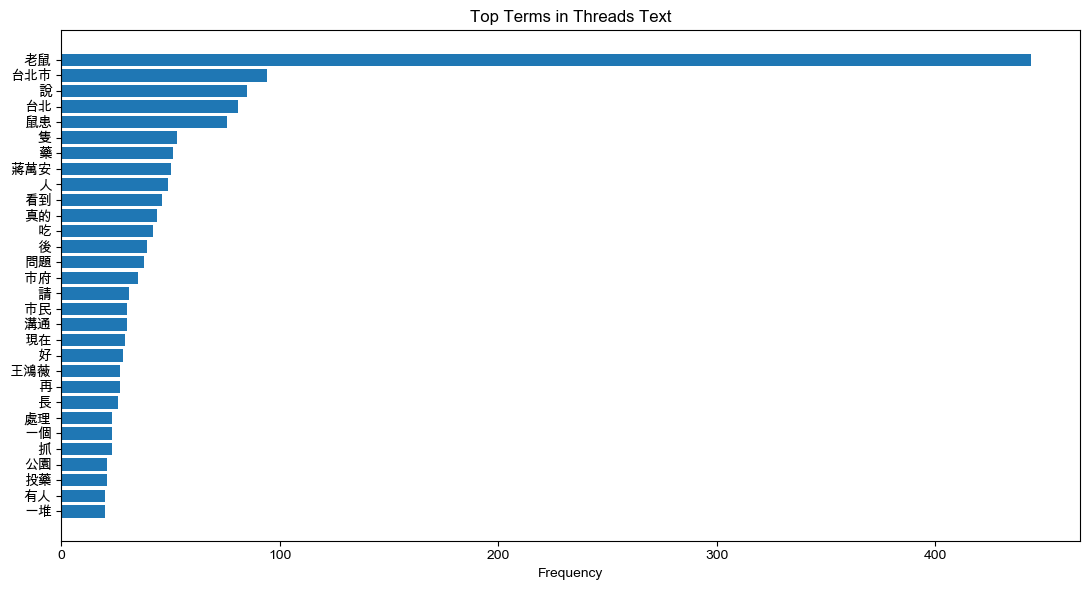

In [37]:
plot_df = top_terms.sort_values('count', ascending=True)
plt.figure(figsize=(11, 6))
plt.barh(plot_df['term'], plot_df['count'])
plt.title('Top Terms in Threads Text')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

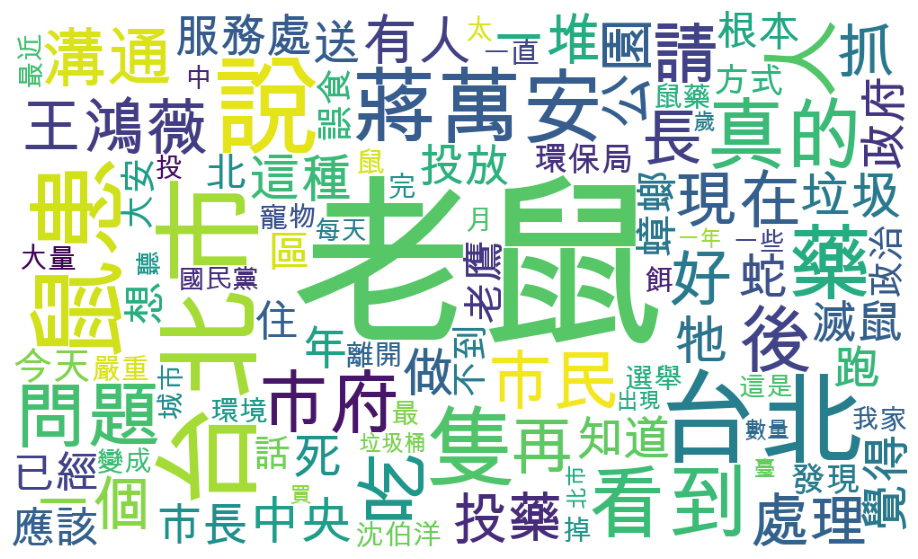

In [45]:
top_terms = pd.DataFrame(Counter(all_tokens).most_common(1000), columns=['term', 'count'])

wc = WordCloud(
    font_path=font_path,
    width=1000,
    height=600,
    background_color='white',
    max_words=100,
    collocations=False
).generate_from_frequencies(dict(zip(top_terms['term'], top_terms['count'])))

plt.figure(figsize=(12, 7))
plt.imshow(wc)
plt.axis('off')
plt.show()